<a href="https://colab.research.google.com/github/sivamamidi/vector_database_L2_distance_Key_word_search/blob/sivanarayana/Variational_auto_encoder_with_L1_distance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras import losses
from scipy.stats import norm

Where do embeddings come from?
Embedding MNIST images and NLP sentences into vectors
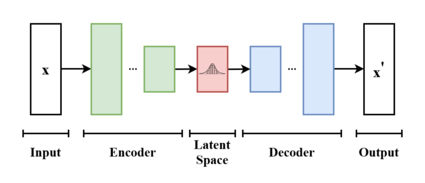

In [ ]:
#load data - training and test
(x_tr, y_tr), (x_te, y_te) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


| Step      | `x_tr` Shape    | `x_te` Shape    | What Happens           |
| --------- | --------------- | --------------- | ---------------------- |
| Load Data | (60000, 28, 28) | (10000, 28, 28) | Raw pixel images       |
| Normalize | (60000, 28, 28) | (10000, 28, 28) | Values scaled to [0–1] |
| Flatten   | (60000, 784)    | (10000, 784)    | 2D images → 1D vectors |


In [ ]:
#Normalize and reshape images (flatten)
x_tr,x_te = x_tr.astype("float32")/255., x_te.astype('float32')/255.
x_tr_flat, x_te_flat = x_tr.reshape(x_tr.shape[0],-1), x_te.reshape(x_te.shape[0],-1)

In [ ]:
print(x_tr.shape, x_te.shape)
print(x_tr_flat.shape, x_te_flat.shape)

(60000, 28, 28) (10000, 28, 28)
(60000, 784) (10000, 784)


In [ ]:
# Neural Network Parameters
batch_size, n_epoch = 100, 50
n_hidden, z_dim = 256, 2

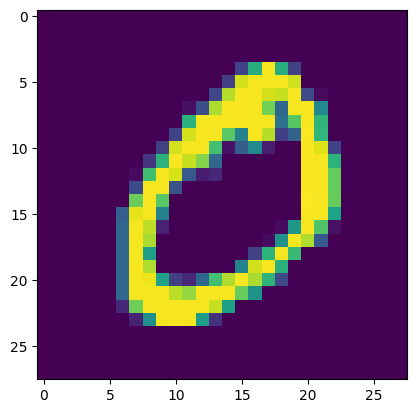

In [ ]:
# Example of a training image
plt.imshow(x_tr[1]);

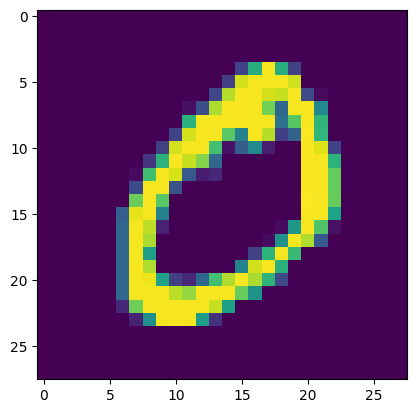

In [ ]:
# Example of a training image
plt.imshow(x_tr[1])

#Sampling function:
It is the core of How a Variational Auto Encoder (VAE) works.

It implements the reparamterization trick, which allows backpropagation through a random sampling step

Let's break it down clearly

In [ ]:
#sampling function

def sampling(args):
  mu, log_var = args
  eps = K.random_normal(shape=(batch_size,z_dim),mean=0.,stddev=1.0)
  return mu + K.exp(log_var) * eps

This **sampling function is the core of how a Variational Autoencoder (VAE) works**.
It implements the **reparameterization trick**, which allows backpropagation through a random sampling step.

Let’s break it down clearly.

---

## ✅ The Code You Gave

```python
def sampling(args):
  mu, log_var = args
  eps = K.random_normal(shape=(batch_size, z_dim), mean=0., stddev=1.0)
  return mu + K.exp(log_var) * eps  
```

---

## ✅ What This Function Is Doing (In One Line)

It **samples a latent vector `z` from a Gaussian distribution** defined by:

* Mean = `mu`
* Variance = `exp(log_var)`

Mathematically:
`z=μ+σ⋅ϵ`

where

`σ=elog_var`
,`ϵ∼N(0,1)`

---

## ✅ What Each Variable Means

### 🔹 1. `mu`

* Output of the encoder
* Represents the **mean** of the latent distribution

### 🔹 2. `log_var`

* Output of the encoder
* Represents the **log of the variance**
* Used instead of variance directly for **numerical stability**

---

### 🔹 3. `eps`

```python
eps = K.random_normal(shape=(batch_size, z_dim), mean=0., stddev=1.0)
```

* Random noise drawn from:
  `ϵ∼N(0,1)`

* Shape:

```
(batch_size, z_dim)
```

So each training sample gets a random latent noise vector.

---

### 🔹 4. Final Line (The Actual Sampling)

```python
return mu + K.exp(log_var) * eps
```

This constructs:

`z=μ+σ⋅ϵ`

where:

`σ=elog_var`


So now:

* `z` is **not purely random**
* It is **centered around `mu`**
* Spread controlled by `log_var`

---

## ✅ Why This Is Needed (VERY Important)

Normally, sampling like this is **not differentiable**:

```python
z = random(mu, sigma)
```

That breaks backpropagation.

✅ This trick rewrites randomness like this:

```text
randomness = eps
trainable parts = mu and log_var
```

So gradients can flow through `mu` and `log_var`.

This is called the **Reparameterization Trick**.

---

## ✅ Simple Numeric Dry Run

Assume:

```python
mu      = [1.0, 2.0]
log_var = [0.0, -0.7]
eps     = [0.5, -1.0]
```

Step 1: Convert log variance to standard deviation:

```
exp(0.0)   = 1.0
exp(-0.7)  ≈ 0.496
```

Step 2: Sample:

```
z1 = 1.0 + 1.0 * 0.5   = 1.5
z2 = 2.0 + 0.496 * -1 = 1.504
```

✅ Final sampled latent vector:

```
z = [1.5, 1.504]
```

---



#Create VAE from scratch

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
#Hyperparameters

batch_size = 100
n_epochs = 1 # small for dry run; change if you actually want to train
n_hidden = 256
z_dim = 2
learning_rate = 1e-3



In [ ]:
#MNIST dataset & dataloaders
 # [0,1], shape (1, 28, 28)
transform = transforms.Compose([transforms.ToTensor()])

In [ ]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


In [ ]:
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [ ]:
class Encode(nn.Module):
    """
    Maps 784-dim input -> 256 -> 128 -> (mu, log_var) in R^z_dim
    """
    def __init__(self,input_dim=784,n_hidden=256,z_dim=2):
      super().__init__()
      # 784 -> 256
      self.fc1 = nn.Linear(input_dim,n_hidden)
       # 256 -> 128
      self.fc2 = nn.Linear(n_hidden,n_hidden//2)
      # 128 -> 2
      self.mu = nn.Linear(n_hidden//2,z_dim)
      # 128 -> 2
      self.log_var = nn.Linear(n_hidden//2,z_dim)
    def forward(self,x):
      #x : (batch_size, 784)
      h = F.relu(self.fc1(x))
      h = F.relu(self.fc2(h))
      mu = self.mu(h)
      log_var = self.log_var(h)
      return mu,log_var

In [ ]:
class Decode(nn.Module):
    #  """
    # Maps latent z in R^2 -> 128 -> 256 -> 784 with sigmoid
    # """
    def __init__(self,z_dim=2,n_hidden=256,output_dim=784):
      super().__init__()
      # 2 -> 128
      self.fc1 = nn.Linear(z_dim,n_hidden//2)
      # 128 --> 256
      self.fc2 = nn.Linear(n_hidden//2,n_hidden)
      #256 --> 784
      self.out = nn.Linear(n_hidden,output_dim)
    def forward(self,z):
      h = F.relu(self.fc1(z))
      h = F.relu(self.fc2(h))
      y = torch.sigmoid(self.out(h))
      return y

In [ ]:
class VAE(nn.Module):
  def __init__(self,input_dim=784,n_hidden=256,z_dim=2):
    super().__init__()
    self.encoder = Encode(input_dim,n_hidden,z_dim)
    self.decoder = Decode(z_dim,n_hidden,input_dim)
  def reparaemterize(self,mu,log_var):
    #Sampling z = mu + exp(log_var) * eps
    eps = torch.rand_like(mu)
    z = mu + torch.exp(log_var) * eps
    return z
  def forward(self,x):
    # #"""
    #     x: (batch_size, 1, 28, 28)
    #     returns: reconstruction, mu, log_var
    #     """
    batch_size = x.shape[0]
    #flatten to (batch_size, 784)
    x_flat = x.view(batch_size,-1)
    mu, log_var = self.encoder(x_flat)
    z = self.reparaemterize(mu,log_var)
    x_recon = self.decoder(z)
    return x_recon,mu,log_var

In [ ]:
def vae_loss(recon_x,x,mu,log_var):
  # recon_x = (batch_size, 784 ) reconstructed
  # x: batch_size, 1, 28,28, original
  # mu, log_var = (batch_size,z_dim)
  #     We'll use BCE summed over all pixels + KL summed over latent dims.
  batch_size = x.shape[0]
  x_flat = x.view(batch_size,-1)
  recon_loss = F.binary_cross_entropy(recon_x,x_flat,reduction='sum')
  # KL term using same express
  kl = 0.5 * torch.sum(mu.pow(2)+torch.exp(log_var)-log_var-1)
  return recon_loss + kl


In [ ]:
# -------------------------
# Instantiate model & optimizer
# -------------------------
model = VAE(input_dim=784,n_hidden=n_hidden,z_dim=z_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

model

VAE(
  (encoder): Encode(
    (fc1): Linear(in_features=784, out_features=256, bias=True)
    (fc2): Linear(in_features=256, out_features=128, bias=True)
    (mu): Linear(in_features=128, out_features=2, bias=True)
    (log_var): Linear(in_features=128, out_features=2, bias=True)
  )
  (decoder): Decode(
    (fc1): Linear(in_features=2, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=256, bias=True)
    (out): Linear(in_features=256, out_features=784, bias=True)
  )
)

In [ ]:
#Dry RUN single forward pass
model.eval()


VAE(
  (encoder): Encode(
    (fc1): Linear(in_features=784, out_features=256, bias=True)
    (fc2): Linear(in_features=256, out_features=128, bias=True)
    (mu): Linear(in_features=128, out_features=2, bias=True)
    (log_var): Linear(in_features=128, out_features=2, bias=True)
  )
  (decoder): Decode(
    (fc1): Linear(in_features=2, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=256, bias=True)
    (out): Linear(in_features=256, out_features=784, bias=True)
  )
)

In [ ]:
model.eval()
with torch.no_grad():
    x_batch, y_batch = next(iter(train_loader))
    x_batch = x_batch.to(device)
    recon, mu, log_var = model(x_batch)
    loss = vae_loss(recon, x_batch, mu, log_var)
print("Input batch shape:      ", x_batch.shape)   # (batch_size, 1, 28, 28)
print("Reconstruction shape:   ", recon.shape)     # (batch_size, 784)
print("mu shape:               ", mu.shape)        # (batch_size, 2)
print("log_var shape:          ", log_var.shape)   # (batch_size, 2)
print("VAE loss (one batch):   ", loss.item())

Input batch shape:       torch.Size([100, 1, 28, 28])
Reconstruction shape:    torch.Size([100, 784])
mu shape:                torch.Size([100, 2])
log_var shape:           torch.Size([100, 2])
VAE loss (one batch):    54497.06640625


In [ ]:
# -------------------------
# OPTIONAL: very short training loop (1 epoch) - still "dry-ish"
# Comment out if you only want definition
# -------------------------

for epoch in range(1,n_epochs+1):
  model.train()
  total_loss = 0
  for batch_idx, (data,_) in enumerate(train_loader):
    data = data.to(device)
    optimizer.zero_grad()
    recon_batch,mu,log_var = model(data)
    loss = vae_loss(recon_batch,data,mu,log_var)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  avg_loss = total_loss / len(train_loader.dataset)
  print(f'Epoch{epoch}, Average loss : {avg_loss:.4f}')



Epoch1, Average loss : 180.0348


| Line            | What it does   | Result Shape       |
| --------------- | -------------- | ------------------ |
| `data`          | Whole batch    | `(100, 1, 28, 28)` |
| `data[0]`       | First image    | `(1, 28, 28)`      |
| `.cpu()`        | Move to CPU    | `(1, 28, 28)`      |
| `.view(28, 28)` | Remove channel | ✅ `(28, 28)`       |


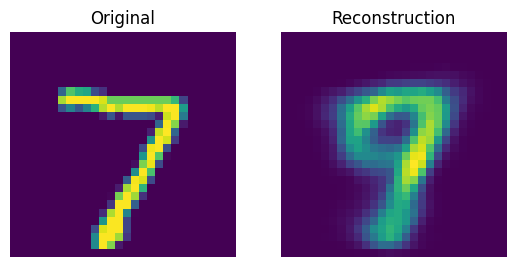

In [ ]:
# -------------------------
# Example: visualize one reconstruction after training
# -------------------------

model.eval()
with torch.no_grad():
    data, _ = next(iter(test_loader))
    data = data.to(device)
    recon, _, _ = model(data)
    # pick first sample
    original = data[0].cpu().view(28, 28)
    reconstructed = recon[0].cpu().view(28, 28)

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(original.numpy())
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstruction")
plt.imshow(reconstructed.numpy())
plt.axis("off")

plt.show()

Excellent — this is the **exact right question to ask** for really understanding latent spaces. Let’s strip this down to the **absolute basics** and remove all confusion ✅

You asked:

> **What is `all_mu`? What are `0` and `1`?**

We’ll use this PyTorch line as reference:

```python
plt.scatter(all_mu[:,0], all_mu[:,1], c=all_labels)
```

---

# ✅ 1. What is `mu` (in plain English)?

For **every image**, your encoder outputs:

```python
mu = [mu_0, mu_1]
```

Because:

```python
z_dim = 2
```

So instead of storing an image as **784 pixels**, the VAE compresses it into just:

```
2 numbers → (mu_0, mu_1)
```

Example:

| Image   | mu_0 | mu_1 |
| ------- | ---- | ---- |
| Digit 7 | 1.3  | -0.4 |
| Digit 0 | -2.1 | 0.9  |
| Digit 3 | 0.5  | 1.7  |

✅ These are the **2D coordinates** of your image in latent space.

---

# ✅ 2. What is `all_mu`?

This is how we built it:

```python
all_mu.append(mu.cpu().numpy())
```

Then later:

```python
all_mu = np.concatenate(all_mu)
```

So:

> ✅ **`all_mu` = ALL 2D latent points for ALL test images**

If you have 10,000 test images:

```text
all_mu.shape = (10000, 2)
```

That means:

* 10,000 rows → one per image
* 2 columns → (mu_0, mu_1)

---

# ✅ 3. What does `all_mu[:, 0]` mean?

Let’s use a tiny example:

```python
all_mu =
[
  [ 1.2, -0.4 ],   # image 0
  [ -2.1, 0.9 ],   # image 1
  [ 0.5, 1.7 ]     # image 2
]
```

Now:

### ✅ `all_mu[:, 0]` means:

> “Give me the **FIRST VALUE from EVERY ROW**”

So:

```python
all_mu[:, 0] = [1.2, -2.1, 0.5]
```

This is:

* The **X-axis coordinates** for every image

---

### ✅ `all_mu[:, 1]` means:

> “Give me the **SECOND VALUE from EVERY ROW**”

So:

```python
all_mu[:, 1] = [-0.4, 0.9, 1.7]
```

This is:

* The **Y-axis coordinates** for every image

---

# ✅ 4. Why is it written this way?

This is called **matrix slicing**:

```python
array[all_rows, specific_column]
```

So:

| Code | Meaning             |
| ---- | ------------------- |
| `:`  | “Take everything”   |
| `0`  | First column (mu₀)  |
| `1`  | Second column (mu₁) |

So:

```python
all_mu[:,0] → all X positions
all_mu[:,1] → all Y positions
```

---

# ✅ 5. What does this line REALLY mean?

```python
plt.scatter(all_mu[:,0], all_mu[:,1], c=all_labels)
```

It literally means:

> “Plot every image as a point where:
>
> * X = first latent number
> * Y = second latent number
> * Color = its true digit label”

---

# ✅ 6. What about `all_labels`?

This is just:

```python
all_labels = [7, 0, 3, 1, 9, 4, ...]
```

So:

✅ It colors:

* All “0” digits one color
* All “1” digits another color
* …
* All “9” digits another color

---

# ✅ 7. ONE-LINE SUPER SIMPLE VERSION

> 🔹 `all_mu` is just a big table where each image is stored as **two numbers instead of 784 pixels**.
> 🔹 `0` means the first number (X-axis).
> 🔹 `1` means the second number (Y-axis).




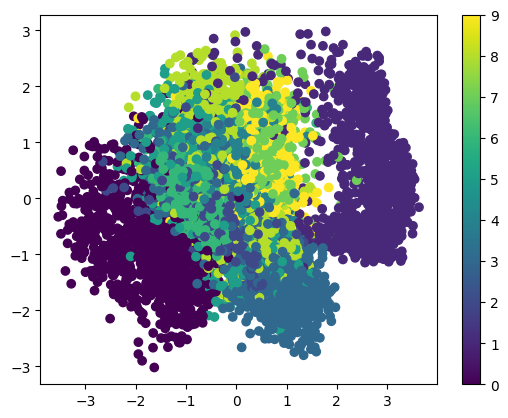

In [ ]:
model.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        _, mu, _ = model(data)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mu = np.concatenate(all_mu)
all_labels = np.concatenate(all_labels)

plt.scatter(all_mu[:,0], all_mu[:,1], c=all_labels)
plt.colorbar()
plt.show()


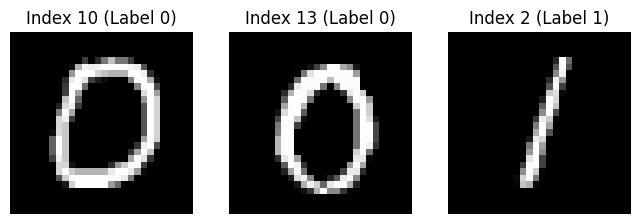

In [ ]:
# Get three test images
img_A, label_A = test_dataset[10]
img_B, label_B = test_dataset[13]
img_C, label_C = test_dataset[2]

plt.figure(figsize=(8, 3))

plt.subplot(1, 3, 1)
plt.imshow(img_A[0], cmap="gray")
plt.title(f"Index 10 (Label {label_A})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_B[0], cmap="gray")
plt.title(f"Index 13 (Label {label_B})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_C[0], cmap="gray")
plt.title(f"Index 2 (Label {label_C})")
plt.axis("off")

plt.show()


In [ ]:
zero_A = all_mu[10]
zero_B = all_mu[13]
one    = all_mu[2]


In [ ]:
print(f"Embedding for the first ZERO is  {zero_A}")
print(f"Embedding for the second ZERO is {zero_B}")
print(f"Embedding for the ONE is         {one}")

Embedding for the first ZERO is  [-1.1888835 -1.443495 ]
Embedding for the second ZERO is [-1.1570876 -1.211315 ]
Embedding for the ONE is         [2.6468494 0.5072811]


Using more advanced models based on the Transformer architechture you can embed sentences aswell

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
#Sentences we want to encode. Example:
sentence = ['The team enjoyed the hike through the meadow',
            'The national park had great views',
            'Olive oil drizzled over pizza tastes delicious']

In [ ]:
#Sentences are encoded by calling model.encode()
embedding = model.encode(sentence)

#Preview the embeddings
print(embedding)

[[ 0.3706198   0.26414257  0.21265689 ...  0.14994544 -0.25794894
  -0.23970775]
 [ 0.6693324   0.40094912 -0.48208395 ...  0.10645888 -1.5067161
  -0.01547362]
 [-0.2655593   0.1117237  -0.1473308  ...  0.42197493  0.88394594
   0.10763928]]


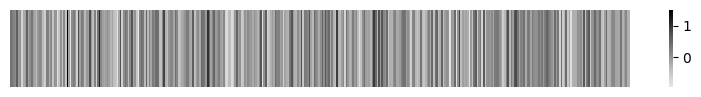

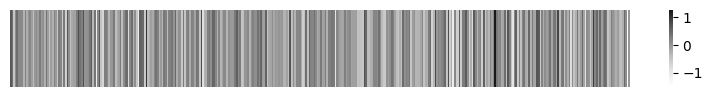

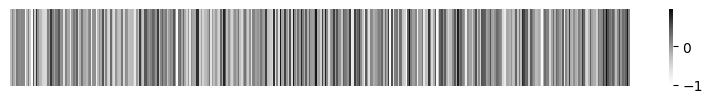

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(embedding[0].reshape(-1,384),cmap="Greys",center=0,square=False)
plt.gcf().set_size_inches(10,1)
plt.axis('off')
plt.show()

sns.heatmap(embedding[1].reshape(-1,384),cmap="Greys",center=0,square=False)
plt.gcf().set_size_inches(10,1)
plt.axis('off')
plt.show()

sns.heatmap(embedding[2].reshape(-1,384),cmap="Greys",center=0,square=False)
plt.gcf().set_size_inches(10,1)
plt.axis('off')
plt.show()

How can we measure the distance between these Image and Sentence Embeddings?
There are many ways to calculate the distances between two vectors.

Here we will cover 4 distance metrics that you might find being used in the context of vector databases:

Euclidean Distance(L2)
Manhattan Distance(L1)
Dot Product
Cosine Distance

#Euclidean Distance(L2)
The length of the shortest path between two points or vectors.

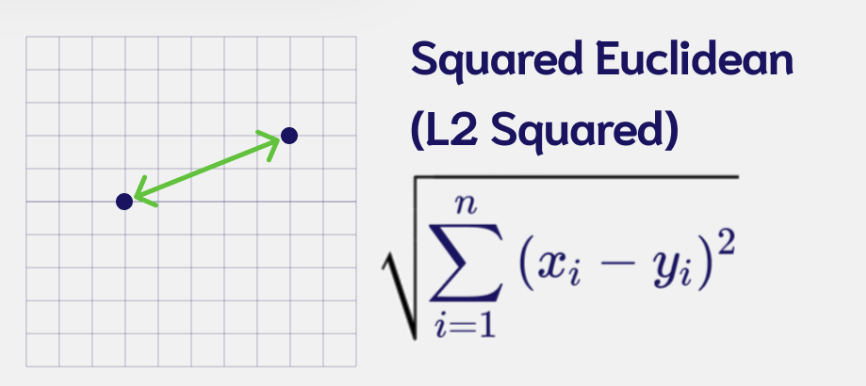

In [ ]:
print(f"Embedding for the first ZERO is  {zero_A}")
print(f"Embedding for the second ZERO is {zero_B}")
print(f"Embedding for the ONE is         {one}")

Embedding for the first ZERO is  [-1.1888835 -1.443495 ]
Embedding for the second ZERO is [-1.1570876 -1.211315 ]
Embedding for the ONE is         [2.6468494 0.5072811]


In [ ]:
# Euclidean Distance
L2 = [(zero_A[i] - zero_B[i])**2 for i in range(len(zero_A))]
L2 = np.sqrt(np.array(L2).sum())
print(L2)

0.23434705


In [ ]:
#An alternative way of doing this
np.linalg.norm((zero_A - zero_B), ord=2)

np.float32(0.23434705)

In [ ]:
#Calculate L2 distances
print("Distance zeroA-zeroB:", np.linalg.norm((zero_A - zero_B), ord=2))
print("Distance zeroA-one:  ", np.linalg.norm((zero_A - one), ord=2))
print("Distance zeroB-one:  ", np.linalg.norm((zero_B - one), ord=2))

Distance zeroA-zeroB: 0.23434705
Distance zeroA-one:   4.303298
Distance zeroB-one:   4.1741476


#Manhattan Distance(L1)
Distance between two points if one was constrained to move only along one axis at a time.

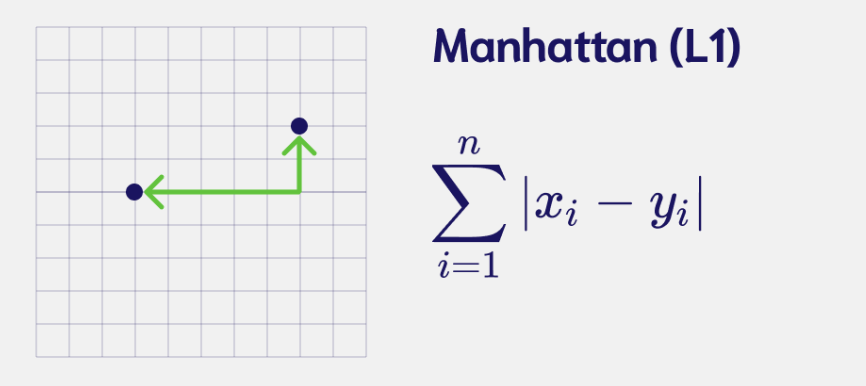

In [ ]:
L1 = [zero_A[i]-zero_B[i] for i in range(len(zero_A))]
L1 = np.abs(L1).sum()
L1

np.float32(0.26397598)

In [ ]:
#an alternative way of doing this is
np.linalg.norm((zero_A - zero_B), ord=1)

np.float32(0.26397598)

In [ ]:
#Calculate L1 distances
print("Distance zeroA-zeroB:", np.linalg.norm((zero_A - zero_B), ord=1))
print("Distance zeroA-one:  ", np.linalg.norm((zero_A - one), ord=1))
print("Distance zeroB-one:  ", np.linalg.norm((zero_B - one), ord=1))

Distance zeroA-zeroB: 0.26397598
Distance zeroA-one:   5.786509
Distance zeroB-one:   5.5225334


#Dot Product
Measures the magnitude of the projection of one vector onto the other

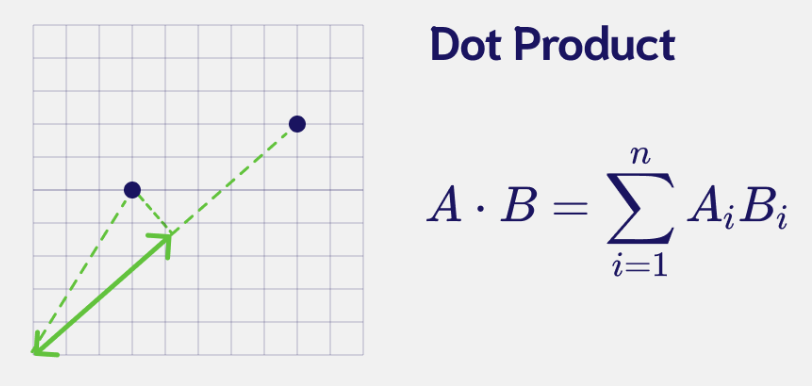

In [ ]:
np.dot(zero_A,zero_B)

np.float32(3.1241698)

In [ ]:
#Calculate Dot products
print("Distance zeroA-zeroB:", np.dot(zero_A, zero_B))
print("Distance zeroA-one:  ", np.dot(zero_A, one))
print("Distance zeroB-one:  ", np.dot(zero_B, one))

Distance zeroA-zeroB: 3.1241698
Distance zeroA-one:   -3.8790536
Distance zeroB-one:   -3.677114


#Cosine Distance
Measure the difference in directionality between vectors.

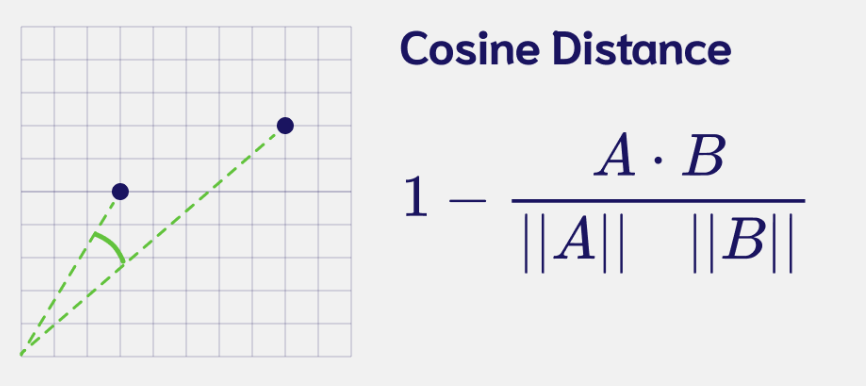

In [ ]:
# Cosine Distance
cosine = 1 - np.dot(zero_A,zero_B)/(np.linalg.norm(zero_A)*np.linalg.norm(zero_B))
print(f"{cosine:.6f}")

0.002702


In [ ]:
zero_A/zero_B

array([1.0274793, 1.191676 ], dtype=float32)

In [ ]:
# Cosine Distance function
def cosine_distance(vec1,vec2):
  cosine = 1 - (np.dot(vec1, vec2)/(np.linalg.norm(vec1)*np.linalg.norm(vec2)))
  return cosine

In [ ]:
#Cosine Distance
print(f"Distance zeroA-zeroB: {cosine_distance(zero_A, zero_B): .6f}")
print(f"Distance zeroA-one:   {cosine_distance(zero_A, one): .6f}")
print(f"Distance zeroB-one:   {cosine_distance(zero_B, one): .6f}")

Distance zeroA-zeroB:  0.002702
Distance zeroA-one:    1.769676
Distance zeroB-one:    1.814499


Now with the sentence embeddings!
Dot Product and Cosine Distance are commonly used in the field of NLP, to evaluate how similar two sentence embeddings are. So here we will only use those two.

embedding0 - 'The team enjoyed the hike through the meadow'

embedding1 - The national park had great views'

embedding2 - 'Olive oil drizzled over pizza tastes delicious'

In [ ]:
# Dot Product
print("Distance 0-1:", np.dot(embedding[0], embedding[1]))
print("Distance 0-2:", np.dot(embedding[0], embedding[2]))
print("Distance 1-2:", np.dot(embedding[1], embedding[2]))

Distance 0-1: 26.497883
Distance 0-2: 2.078579
Distance 1-2: 4.0192137


In [ ]:
#Cosine Distance
print("Distance 0-1: ", cosine_distance(embedding[0], embedding[1]))
print("Distance 0-2: ", cosine_distance(embedding[0], embedding[2]))
print("Distance 1-2: ", cosine_distance(embedding[1], embedding[2]))

Distance 0-1:  0.53503364
Distance 0-2:  0.9639393
Distance 1-2:  0.9288791
